<a href="https://colab.research.google.com/github/essanchristian-maker/DI-Bootcamp/blob/master/Week2_Day4_Exercices_XP_NINJA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

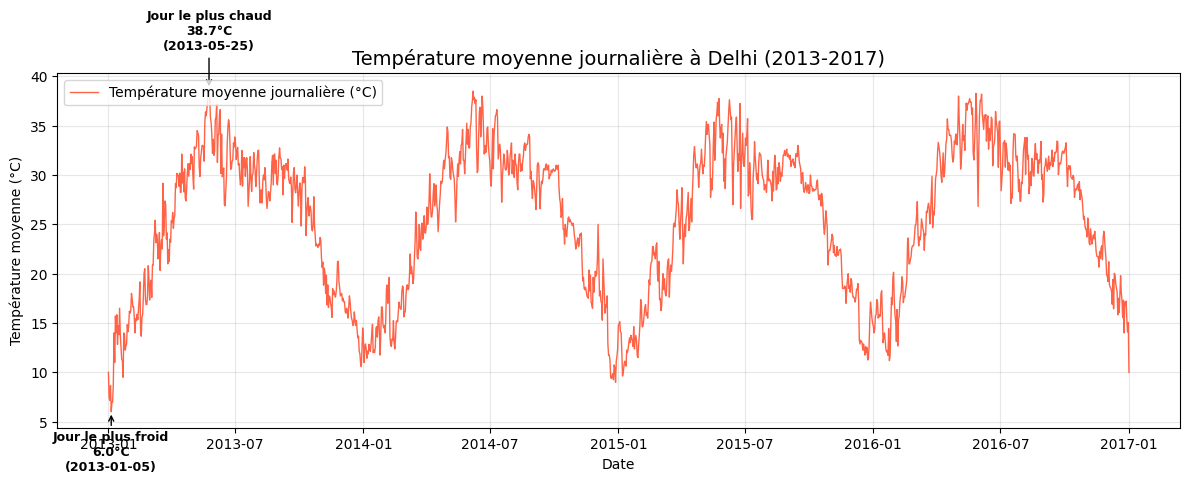

Enseignements tirés de la visualisation :
- Le jour le plus chaud du dataset est le 2013-05-25 avec 38.7°C.
- Le jour le plus froid du dataset est le 2013-01-05 avec 6.0°C.
- En moyenne, le mois le plus chaud est le mois 6 (33.7°C en moyenne).
- En moyenne, le mois le plus froid est le mois 1 (13.3°C en moyenne).
- On observe un cycle saisonnier clair qui se répète chaque année, avec une amplitude marquée entre l'hiver et l'été à Delhi.


In [15]:
# ============================================================
# Exercice 1 : Graphique en ligne annoté - Températures à Delhi
# Source : Kaggle - Daily Climate Time Series Data (sumanthvrao)
# ============================================================
# Objectif : visualiser l'évolution de la température moyenne
# journalière à Delhi, et mettre en évidence les jours les plus
# chauds et les plus froids enregistrés dans le dataset.

# --- 1. Importation des bibliothèques nécessaires ---
import pandas as pd
import matplotlib.pyplot as plt

# --- 2. Chargement du vrai dataset ---
df = pd.read_csv("DailyDelhiClimateTrain.csv")

# La colonne "date" est actuellement du texte -> on la convertit
# en vrai type datetime pour que Matplotlib l'affiche correctement
# sur l'axe X (et pour pouvoir trier chronologiquement).
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")

# --- 3. Création du graphique en ligne ---
plt.figure(figsize=(12, 5))

plt.plot(
    df["date"],
    df["meantemp"],
    color="tomato",
    linewidth=1,
    label="Température moyenne journalière (°C)"
)

# --- 4. Repérage automatique des événements extrêmes ---
# On cherche la ligne où meantemp est maximale, puis minimale,
# pour pouvoir les annoter sur le graphique.
hottest_row = df.loc[df["meantemp"].idxmax()]
coldest_row = df.loc[df["meantemp"].idxmin()]

# --- 5. Annotation du jour le plus chaud ---
plt.annotate(
    f"Jour le plus chaud\n{hottest_row['meantemp']:.1f}°C\n({hottest_row['date'].date()})",
    xy=(hottest_row["date"], hottest_row["meantemp"]),
    xytext=(hottest_row["date"], hottest_row["meantemp"] + 4),
    arrowprops=dict(facecolor="black", arrowstyle="->"),
    fontsize=9,
    fontweight="bold",
    ha="center"
)

# --- 6. Annotation du jour le plus froid ---
plt.annotate(
    f"Jour le plus froid\n{coldest_row['meantemp']:.1f}°C\n({coldest_row['date'].date()})",
    xy=(coldest_row["date"], coldest_row["meantemp"]),
    xytext=(coldest_row["date"], coldest_row["meantemp"] - 6),
    arrowprops=dict(facecolor="black", arrowstyle="->"),
    fontsize=9,
    fontweight="bold",
    ha="center"
)

# --- 7. Personnalisation pour la clarté ---
plt.title("Température moyenne journalière à Delhi (2013-2017)", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Température moyenne (°C)")
plt.legend(loc="upper left")
plt.grid(alpha=0.3)
plt.tight_layout()

# --- 8. Affichage du graphique ---
plt.show()

# ============================================================
# Enseignements tirés de la visualisation
# ============================================================
# On calcule la température moyenne par mois (toutes années confondues)
# pour identifier objectivement le cycle saisonnier, en plus des deux
# extrêmes déjà annotés sur le graphique.
df["month"] = df["date"].dt.month
monthly_avg = df.groupby("month")["meantemp"].mean()

hottest_month = monthly_avg.idxmax()
coldest_month = monthly_avg.idxmin()

print("Enseignements tirés de la visualisation :")
print(f"- Le jour le plus chaud du dataset est le {hottest_row['date'].date()} "
      f"avec {hottest_row['meantemp']:.1f}°C.")
print(f"- Le jour le plus froid du dataset est le {coldest_row['date'].date()} "
      f"avec {coldest_row['meantemp']:.1f}°C.")
print(f"- En moyenne, le mois le plus chaud est le mois {hottest_month} "
      f"({monthly_avg[hottest_month]:.1f}°C en moyenne).")
print(f"- En moyenne, le mois le plus froid est le mois {coldest_month} "
      f"({monthly_avg[coldest_month]:.1f}°C en moyenne).")
print("- On observe un cycle saisonnier clair qui se répète chaque année, "
      "avec une amplitude marquée entre l'hiver et l'été à Delhi.")

/tmp/ipykernel_2657/3860678636.py:13: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("city_temperature.csv")  # adapte le nom de fichier si besoin


Nombre de jours trouvés pour Houston, Texas entre 2015-01-01 et 2015-12-31 : 365
                                         Region  Month  Day  Year  \
Country State City    Date                                          
US      Texas Houston 2015-01-01  North America      1    1  2015   
                      2015-01-02  North America      1    2  2015   
                      2015-01-03  North America      1    3  2015   
                      2015-01-04  North America      1    4  2015   
                      2015-01-05  North America      1    5  2015   

                                  AvgTemperature  
Country State City    Date                        
US      Texas Houston 2015-01-01            43.3  
                      2015-01-02            48.5  
                      2015-01-03            50.4  
                      2015-01-04            45.5  
                      2015-01-05            39.8  

Température moyenne à Houston (Texas) sur la période : 69.7°F


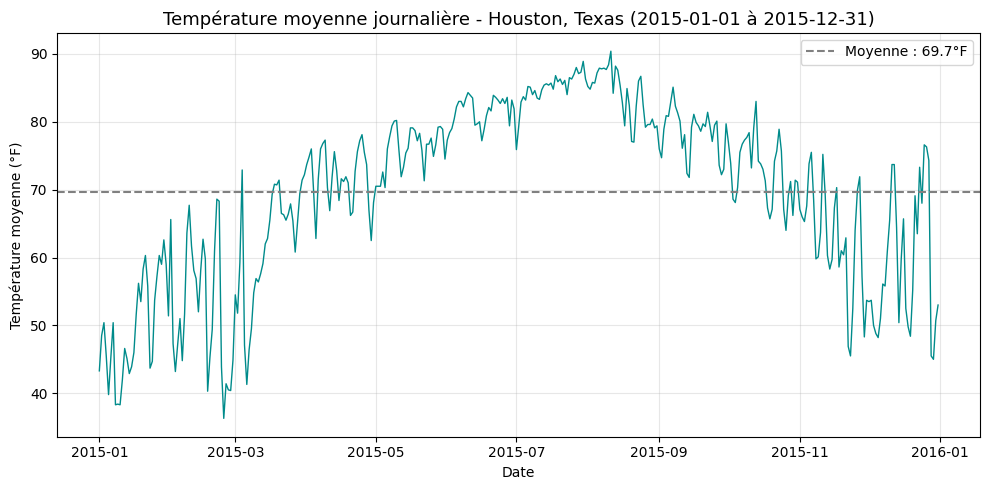

In [19]:
# ============================================================
# Exercice 2 : Filtrage hiérarchique et visualisation
# Source : Kaggle - Daily Temperature of Major Cities (sudalairajkumar)
# ============================================================
# Objectif : extraire et analyser la température d'un état, d'une ville
# et d'une plage de dates précis, grâce à l'indexation hiérarchique.

# --- 1. Importation des bibliothèques nécessaires ---
import pandas as pd
import matplotlib.pyplot as plt

# --- 2. Chargement du dataset ---
df = pd.read_csv("city_temperature.csv")  # adapte le nom de fichier si besoin

# --- 3. Nettoyage des données ---
# Ce dataset code les valeurs manquantes de température avec "-99"
# (au lieu d'un vrai NaN) -> il faut les retirer avant toute analyse,
# sinon elles fausseraient la moyenne et le graphique.
df = df[df["AvgTemperature"] != -99]

# --- 4. Reconstruction d'une vraie colonne Date ---
# Year, Month, Day sont séparés -> on les combine en une seule date.
# errors="coerce" transforme en NaT les dates invalides (ex: jour 0)
# qu'on retire ensuite avec dropna().
df["Date"] = pd.to_datetime(
    dict(year=df["Year"], month=df["Month"], day=df["Day"]),
    errors="coerce"
)
df = df.dropna(subset=["Date"])

# --- 5. Mise en place de l'indexation hiérarchique ---
# 4 niveaux, comme demandé : Country > State > City > Date
df_indexed = df.set_index(["Country", "State", "City", "Date"]).sort_index()

# --- 6. Définition des critères de filtrage (à adapter selon le besoin) ---
country = "US"
state = "Texas"
city = "Houston"
start_date = "2015-01-01"
end_date = "2015-12-31"

# --- 7. Filtrage via l'index hiérarchique ---
# IndexSlice permet de mélanger des valeurs exactes (pays, état, ville)
# avec une plage de dates (slice) sur le dernier niveau de l'index.
idx = pd.IndexSlice
filtered = df_indexed.loc[idx[country, state, city, start_date:end_date], :]

print(f"Nombre de jours trouvés pour {city}, {state} entre {start_date} et {end_date} : {len(filtered)}")
print(filtered.head())

# --- 8. Calcul de la température moyenne sur la période sélectionnée ---
avg_temp = filtered["AvgTemperature"].mean()
print(f"\nTempérature moyenne à {city} ({state}) sur la période : {avg_temp:.1f}°F")

# --- 9. Visualisation avec un graphique en ligne ---
# On récupère les dates depuis l'index (niveau "Date") pour l'axe X.
dates = filtered.index.get_level_values("Date")

plt.figure(figsize=(10, 5))
plt.plot(dates, filtered["AvgTemperature"], color="darkcyan", linewidth=1)
plt.axhline(avg_temp, color="gray", linestyle="--", label=f"Moyenne : {avg_temp:.1f}°F")

plt.title(f"Température moyenne journalière - {city}, {state} ({start_date} à {end_date})", fontsize=13)
plt.xlabel("Date")
plt.ylabel("Température moyenne (°F)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# Explication du processus
# ============================================================
# 1. Nettoyage : retrait des valeurs sentinelles (-99) qui représentent
#    des données manquantes dans ce dataset spécifique.
# 2. Reconstruction de la date : Year/Month/Day séparés ne permettent pas
#    de trier ou filtrer par période -> on les combine en une vraie Date.
# 3. Indexation hiérarchique (Country > State > City > Date) : permet de
#    cibler directement un sous-ensemble précis sans écrire 4 conditions
#    "==" en chaîne (ex: df[(df.Country==...) & (df.State==...) & ...]).
# 4. IndexSlice : indispensable pour combiner des valeurs exactes
#    (pays/état/ville) avec une plage continue (les dates) dans un même
#    appel .loc[] sur un MultiIndex trié.
# 5. La moyenne et le graphique donnent une vue à la fois chiffrée et
#    visuelle de la période choisie, avec une ligne de référence (moyenne)
#    pour repérer facilement les écarts au-dessus/en dessous de la normale.

Combien de graphiques veux-tu afficher (1 à 9) ? 9


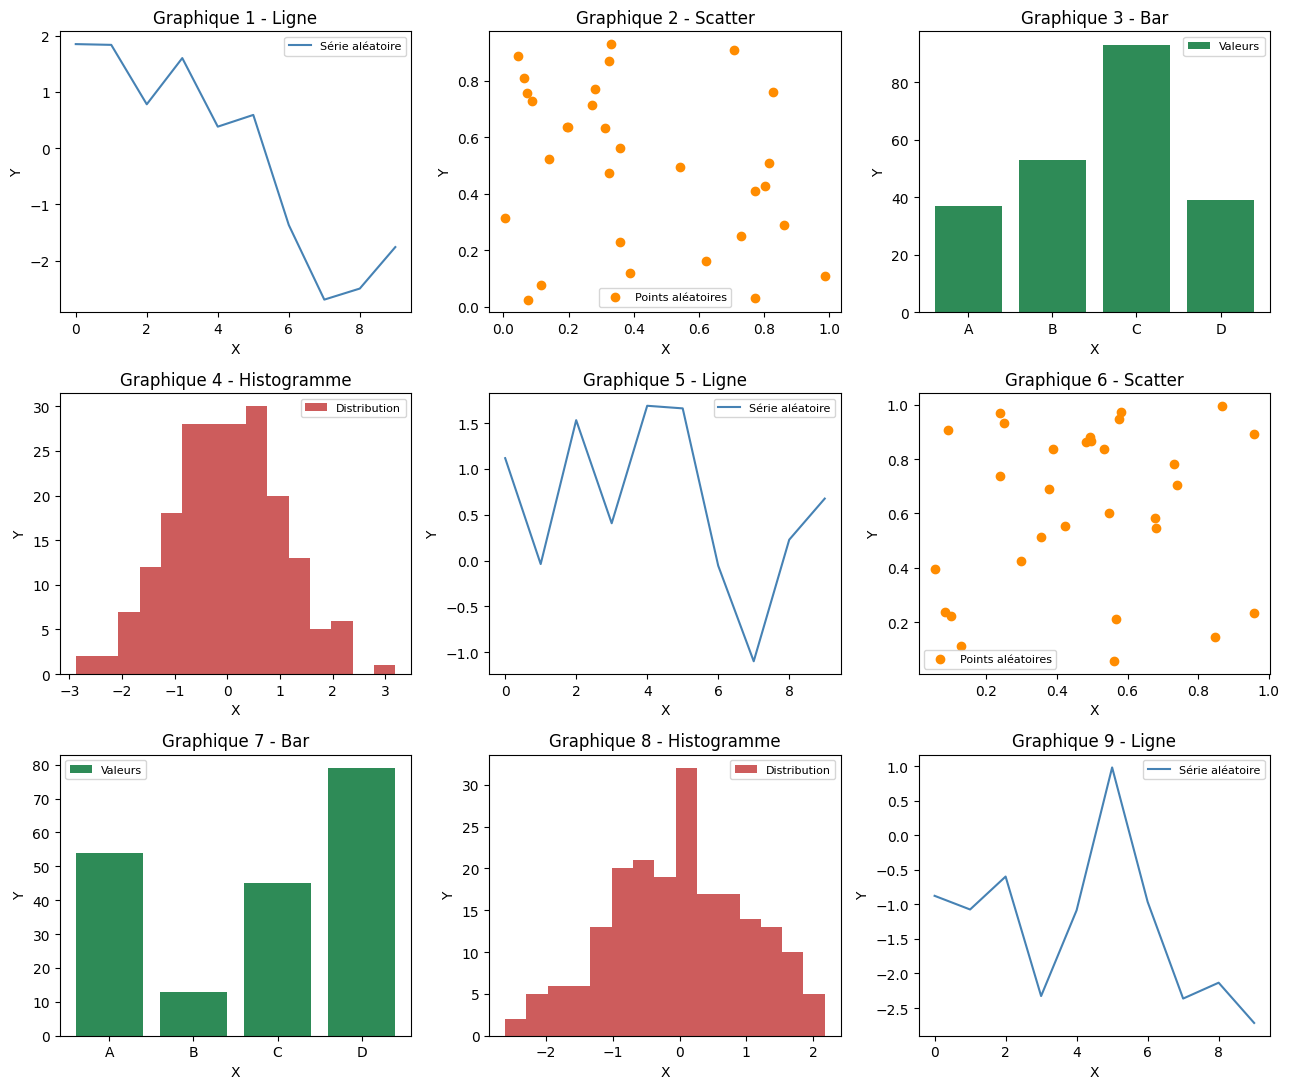

In [20]:
# ============================================================
# Exercice 3 : Configuration dynamique de sous-graphiques (3x3)
# ============================================================
# Objectif : demander à l'utilisateur combien de graphiques afficher
# (jusqu'à 9), puis remplir une grille 3x3 avec différents types de
# graphiques (ligne, scatter, bar, histogramme) à partir de données
# aléatoires.

# --- 1. Importation des bibliothèques nécessaires ---
import matplotlib.pyplot as plt
import numpy as np

# --- 2. Interaction utilisateur ---
# input() renvoie toujours du texte -> on convertit en entier avec int().
# On utilise min()/max() pour s'assurer que la valeur reste entre 1 et 9,
# même si l'utilisateur entre un nombre hors limites.
n_plots = int(input("Combien de graphiques veux-tu afficher (1 à 9) ? "))
n_plots = max(1, min(n_plots, 9))

# --- 3. Liste des types de graphiques à alterner ---
plot_types = ["line", "scatter", "bar", "histogram"]

# --- 4. Création de la grille 3x3 ---
fig, axes = plt.subplots(3, 3, figsize=(13, 11))
axes = axes.flatten()  # transforme la grille 3x3 en une liste de 9 axes,
                        # plus simple à parcourir avec une boucle for

# --- 5. Remplissage de chaque case de la grille ---
for i in range(9):
    ax = axes[i]

    if i < n_plots:
        # On alterne le type de graphique avec le modulo (%),
        # pour boucler sur les 4 types même si n_plots > 4.
        plot_type = plot_types[i % len(plot_types)]

        if plot_type == "line":
            x = np.arange(0, 10)
            y = np.random.randn(10).cumsum()  # marche aléatoire
            ax.plot(x, y, color="steelblue", label="Série aléatoire")
            ax.set_title(f"Graphique {i + 1} - Ligne")

        elif plot_type == "scatter":
            x = np.random.rand(30)
            y = np.random.rand(30)
            ax.scatter(x, y, color="darkorange", label="Points aléatoires")
            ax.set_title(f"Graphique {i + 1} - Scatter")

        elif plot_type == "bar":
            categories = ["A", "B", "C", "D"]
            values = np.random.randint(10, 100, size=4)
            ax.bar(categories, values, color="seagreen", label="Valeurs")
            ax.set_title(f"Graphique {i + 1} - Bar")

        elif plot_type == "histogram":
            data = np.random.randn(200)
            ax.hist(data, bins=15, color="indianred", label="Distribution")
            ax.set_title(f"Graphique {i + 1} - Histogramme")

        # Éléments communs à chaque sous-graphique rempli
        ax.set_xlabel("X")
        ax.set_ylabel("Y")
        ax.legend(fontsize=8)

    else:
        # Cases restantes de la grille 3x3 -> masquées car non utilisées
        ax.axis("off")

# --- 6. Affichage final ---
plt.tight_layout()
plt.show()



Nombre total de vins dans le dataset fictif : 1400

Top 5 pays par nombre de listings : ['France', 'Italy', 'Spain', 'Argentina', 'Chile']


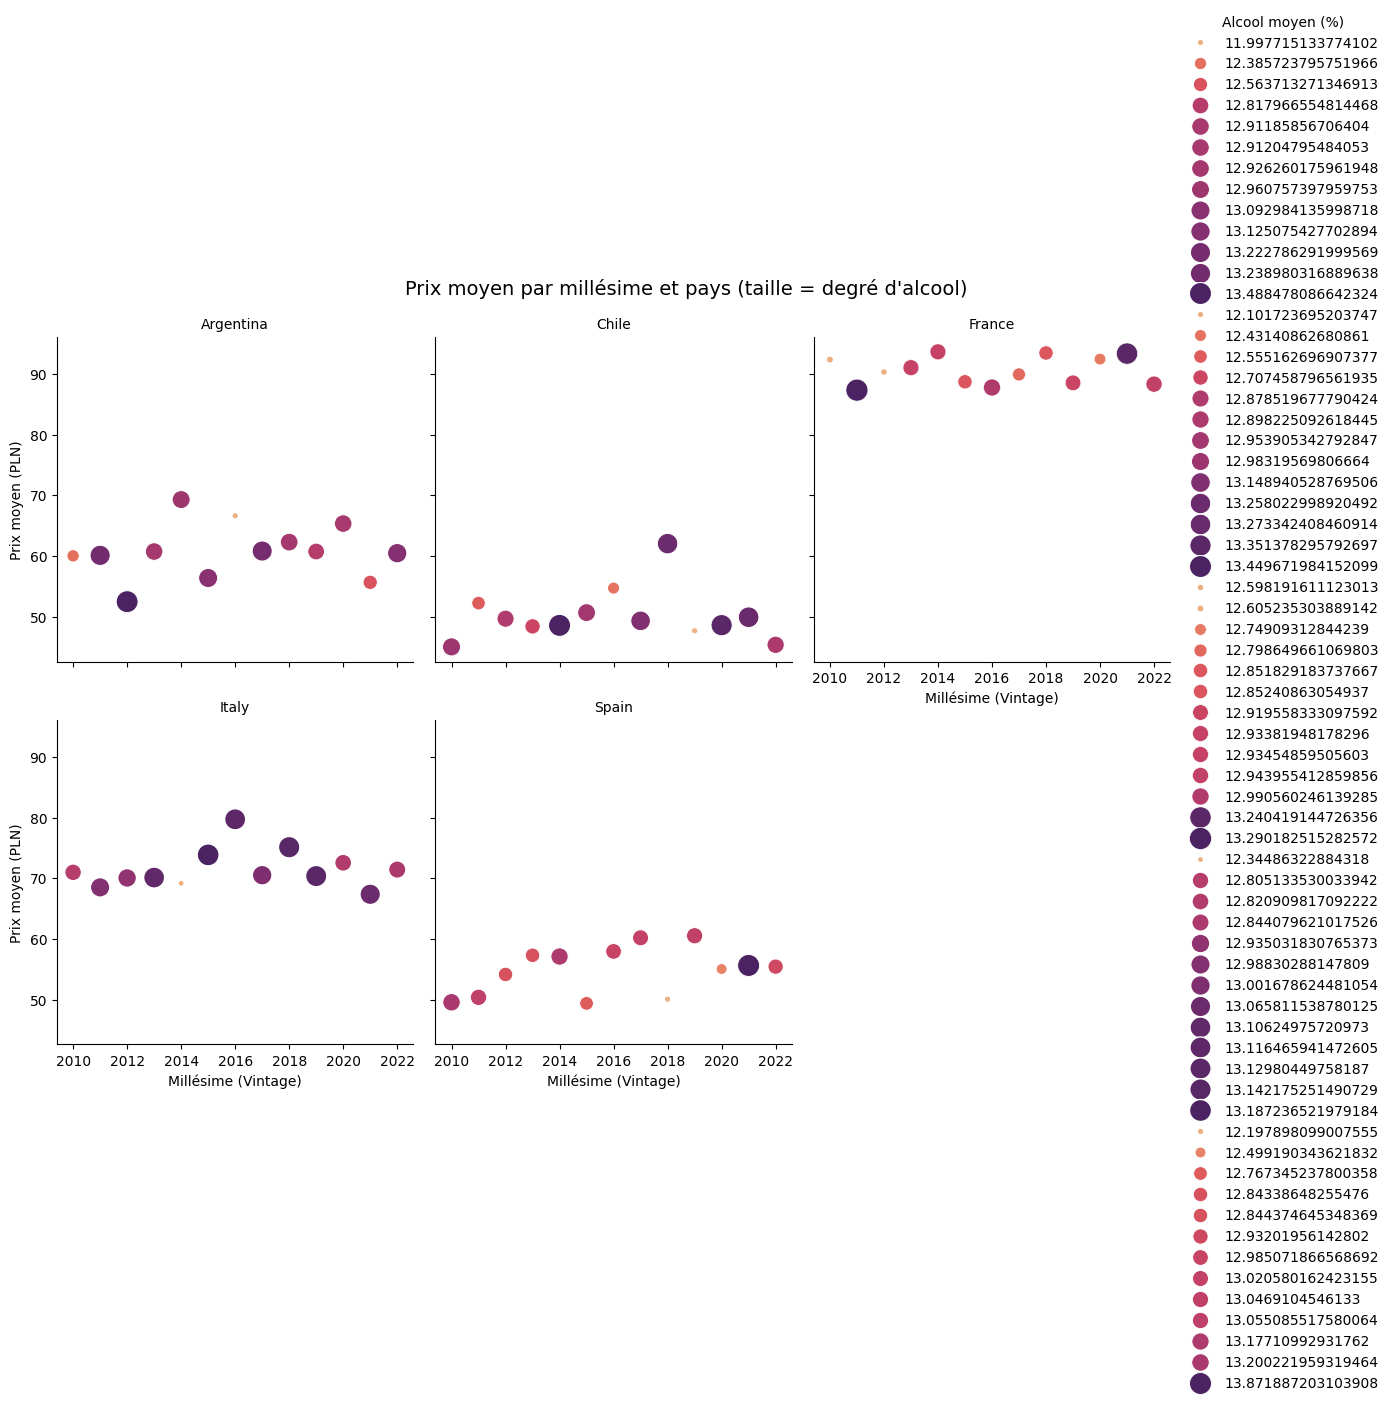

In [21]:
# ============================================================
# Exercice 4 : Analyse multi-dimensionnelle des caractéristiques du vin
# ============================================================
# Objectif : comparer prix moyen, millésime et degré d'alcool des vins,
# pays par pays, parmi les 5 pays ayant le plus de vins listés.

# --- 1. Importation des bibliothèques nécessaires ---
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

np.random.seed(42)  # pour des résultats reproductibles

# --- 2. Création d'un dataset fictif ---
# On définit un nombre de vins différent par pays, pour simuler le fait
# que certains pays ont beaucoup plus de vins "listés" que d'autres.
listings_per_country = {
    "France": 320,
    "Italy": 290,
    "Spain": 180,
    "Argentina": 150,
    "Chile": 140,
    "USA": 90,
    "Portugal": 80,
    "Germany": 60,
    "Australia": 50,
    "South Africa": 40,
}

# Prix moyen "de base" par pays (certains pays sont globalement plus chers)
base_price_per_country = {
    "France": 90, "Italy": 70, "Spain": 55, "Argentina": 60, "Chile": 50,
    "USA": 100, "Portugal": 45, "Germany": 75, "Australia": 65, "South Africa": 48
}

rows = []
for country, n_listings in listings_per_country.items():
    vintages = np.random.randint(2010, 2023, size=n_listings)       # millésime
    base_price = base_price_per_country[country]
    prices = base_price + np.random.normal(0, 15, size=n_listings)   # prix en PLN
    prices = np.clip(prices, 20, None)                                # évite les prix négatifs
    alcohol = np.random.uniform(11, 15, size=n_listings)              # degré d'alcool (%)

    for v, p, a in zip(vintages, prices, alcohol):
        rows.append({"Country": country, "Vintage": v, "Price_PLN": p, "Alcohol_content": a})

df = pd.DataFrame(rows)

print(f"Nombre total de vins dans le dataset fictif : {len(df)}")

# --- 3. Sélection des 5 pays ayant le plus de vins listés ---
# value_counts() compte le nombre de lignes par pays = nombre de "listings"
top5_countries = df["Country"].value_counts().head(5).index.tolist()
print(f"\nTop 5 pays par nombre de listings : {top5_countries}")

df_top5 = df[df["Country"].isin(top5_countries)]

# --- 4. Regroupement par pays et millésime ---
# On calcule le prix moyen et le degré d'alcool moyen pour chaque
# combinaison (pays, millésime), afin d'avoir un point par groupe
# plutôt qu'un nuage de points individuels trop dense.
grouped = (
    df_top5
    .groupby(["Country", "Vintage"], as_index=False)
    .agg(Avg_Price=("Price_PLN", "mean"), Avg_Alcohol=("Alcohol_content", "mean"))
)

# --- 5. Création de la grille de graphiques avec FacetGrid ---
# col="Country" -> un sous-graphique par pays
# size="Avg_Alcohol" -> la taille des points reflète le degré d'alcool moyen
g = sns.FacetGrid(grouped, col="Country", col_wrap=3, height=4, sharey=True)

g.map_dataframe(
    sns.scatterplot,
    x="Vintage",
    y="Avg_Price",
    size="Avg_Alcohol",
    sizes=(20, 250),     # taille min/max des points
    hue="Avg_Alcohol",   # couleur en plus de la taille, pour mieux distinguer
    palette="flare",
    legend="full"
)

# --- 6. Personnalisation : titres et légende ---
g.set_titles("{col_name}")
g.set_axis_labels("Millésime (Vintage)", "Prix moyen (PLN)")
g.add_legend(title="Alcool moyen (%)")
g.fig.suptitle("Prix moyen par millésime et pays (taille = degré d'alcool)", y=1.03, fontsize=14)

plt.show()

Valeurs manquantes par colonne :
Country            0
Vintage            0
Price_PLN          0
Alcohol_content    0
dtype: int64


Résultats sur le jeu de test :
Régression linéaire -> RMSE : 15.26 PLN | R² : 0.553
Random Forest       -> RMSE : 17.18 PLN | R² : 0.434


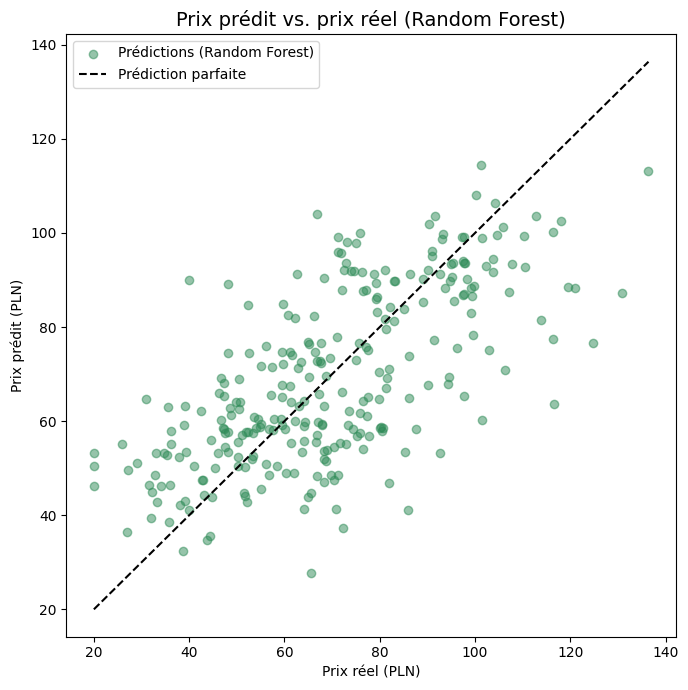

In [22]:
# ============================================================
# Exercice 5 : Prédiction du prix du vin avec Machine Learning
# ============================================================
# Objectif : entraîner un modèle de régression pour prédire le prix
# (en PLN) à partir du pays, du millésime et du degré d'alcool.

# --- 1. Importation des bibliothèques nécessaires ---
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

np.random.seed(42)

# --- 2. Recréation du même dataset fictif que l'Exercice 4 ---
# (même seed -> mêmes données, pour rester cohérent entre les exercices)
listings_per_country = {
    "France": 320, "Italy": 290, "Spain": 180, "Argentina": 150, "Chile": 140,
    "USA": 90, "Portugal": 80, "Germany": 60, "Australia": 50, "South Africa": 40,
}
base_price_per_country = {
    "France": 90, "Italy": 70, "Spain": 55, "Argentina": 60, "Chile": 50,
    "USA": 100, "Portugal": 45, "Germany": 75, "Australia": 65, "South Africa": 48
}

rows = []
for country, n_listings in listings_per_country.items():
    vintages = np.random.randint(2010, 2023, size=n_listings)
    base_price = base_price_per_country[country]
    prices = np.clip(base_price + np.random.normal(0, 15, size=n_listings), 20, None)
    alcohol = np.random.uniform(11, 15, size=n_listings)
    for v, p, a in zip(vintages, prices, alcohol):
        rows.append({"Country": country, "Vintage": v, "Price_PLN": p, "Alcohol_content": a})

df = pd.DataFrame(rows)

# --- 3. Prétraitement des données ---

# 3a. Gestion des valeurs manquantes (aucune ici, mais on vérifie quand même
# -> bonne pratique systématique avant tout entraînement de modèle)
print(f"Valeurs manquantes par colonne :\n{df.isnull().sum()}\n")
df = df.dropna()

# 3b. Encodage de la variable catégorielle "Country"
# pd.get_dummies() crée une colonne binaire (0/1) par pays
# (drop_first=True évite la redondance entre les colonnes créées)
df_encoded = pd.get_dummies(df, columns=["Country"], drop_first=True)

# 3c. Séparation des features (X) et de la cible (y)
X = df_encoded.drop(columns=["Price_PLN"])
y = df_encoded["Price_PLN"]

# 3d. Normalisation des variables numériques
# Important pour la régression linéaire, qui est sensible aux échelles
# (Vintage ~ 2010-2022, Alcohol_content ~ 11-15 -> échelles très différentes)
numeric_cols = ["Vintage", "Alcohol_content"]
scaler = StandardScaler()
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])

# --- 4. Séparation en jeu d'entraînement et de test ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# --- 5. Entraînement de deux modèles de régression ---

# Modèle 1 : Régression linéaire (référence simple)
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

# Modèle 2 : Random Forest (capture les relations non linéaires)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# --- 6. Évaluation des modèles (RMSE et R²) ---
def evaluate(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{name} -> RMSE : {rmse:.2f} PLN | R² : {r2:.3f}")
    return rmse, r2

print("\nRésultats sur le jeu de test :")
evaluate("Régression linéaire", y_test, y_pred_lr)
evaluate("Random Forest      ", y_test, y_pred_rf)

# --- 7. Visualisation : prix prédit vs. prix réel (Random Forest) ---
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred_rf, alpha=0.5, color="seagreen", label="Prédictions (Random Forest)")

# Ligne diagonale de référence : si le modèle était parfait,
# tous les points seraient exactement sur cette ligne (prédit = réel)
min_val, max_val = y_test.min(), y_test.max()
plt.plot([min_val, max_val], [min_val, max_val], color="black", linestyle="--", label="Prédiction parfaite")

plt.title("Prix prédit vs. prix réel (Random Forest)", fontsize=14)
plt.xlabel("Prix réel (PLN)")
plt.ylabel("Prix prédit (PLN)")
plt.legend()
plt.tight_layout()
plt.show()

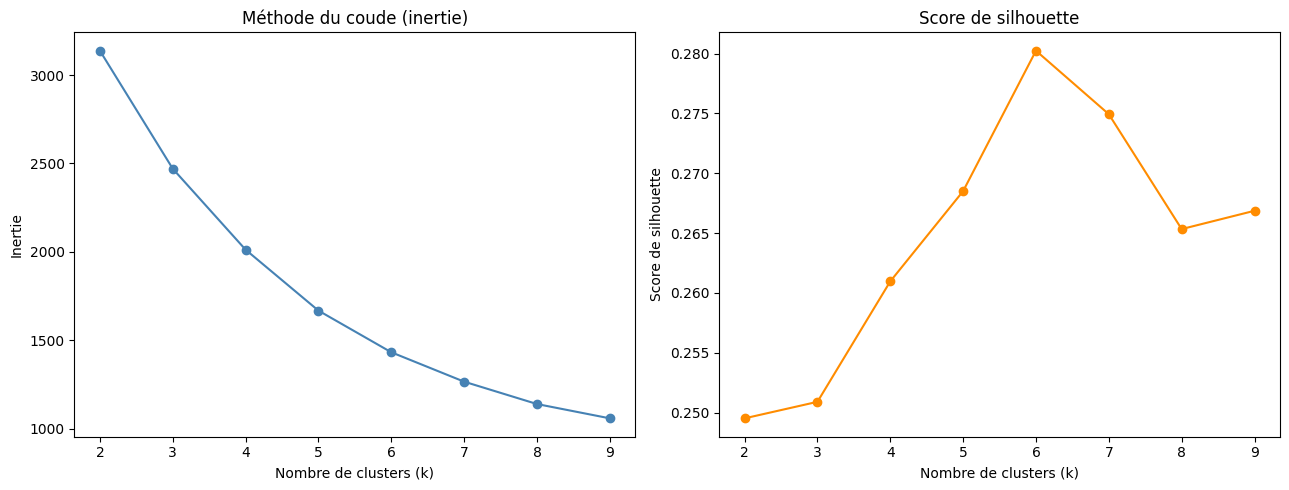

Nombre de clusters retenu (meilleur score de silhouette) : 6
Variance totale expliquée par les 2 composantes PCA : 67.6%


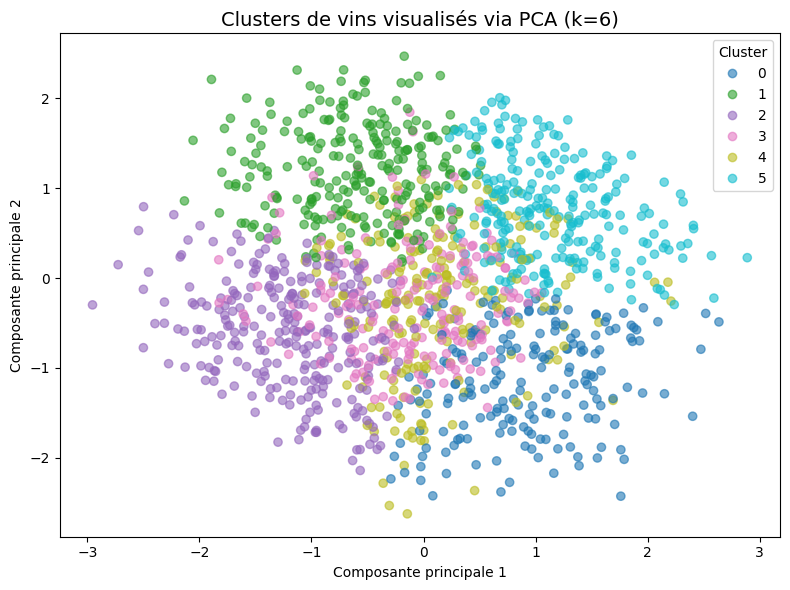


Caractéristiques moyennes par cluster :
         Vintage  Price_PLN  Alcohol_content
Cluster                                     
0        2013.35      94.03            13.75
1        2019.56      51.44            12.29
2        2012.66      60.89            11.93
3        2012.89      51.44            13.98
4        2017.52      94.28            11.93
5        2019.56      73.52            14.10

Pays les plus fréquents par cluster :
Cluster 0 : {'France': 87, 'Italy': 43, 'USA': 40}
Cluster 1 : {'Spain': 52, 'Italy': 49, 'Chile': 46}
Cluster 2 : {'Italy': 64, 'Spain': 42, 'Argentina': 38}
Cluster 3 : {'Spain': 46, 'Chile': 34, 'Italy': 33}
Cluster 4 : {'France': 117, 'Italy': 36, 'USA': 34}
Cluster 5 : {'Italy': 65, 'France': 61, 'Spain': 30}


In [23]:
# ============================================================
# Exercice 6 : Clustering pour identifier des vins similaires
# ============================================================

# --- 1. Importation des bibliothèques nécessaires ---
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

np.random.seed(42)

# --- 2. Recréation du même dataset fictif que les exercices 4 et 5 ---
listings_per_country = {
    "France": 320, "Italy": 290, "Spain": 180, "Argentina": 150, "Chile": 140,
    "USA": 90, "Portugal": 80, "Germany": 60, "Australia": 50, "South Africa": 40,
}
base_price_per_country = {
    "France": 90, "Italy": 70, "Spain": 55, "Argentina": 60, "Chile": 50,
    "USA": 100, "Portugal": 45, "Germany": 75, "Australia": 65, "South Africa": 48
}

rows = []
for country, n_listings in listings_per_country.items():
    vintages = np.random.randint(2010, 2023, size=n_listings)
    base_price = base_price_per_country[country]
    prices = np.clip(base_price + np.random.normal(0, 15, size=n_listings), 20, None)
    alcohol = np.random.uniform(11, 15, size=n_listings)
    for v, p, a in zip(vintages, prices, alcohol):
        rows.append({"Country": country, "Vintage": v, "Price_PLN": p, "Alcohol_content": a})

df = pd.DataFrame(rows)

# --- 3. Prétraitement ---
# 3a. Valeurs manquantes : vérification (aucune ici, mais bonne pratique)
df = df.dropna()

# 3b. On garde uniquement les variables numériques pour le clustering
# (K-means se base sur des distances -> il a besoin de valeurs numériques)
features = df[["Vintage", "Price_PLN", "Alcohol_content"]]

# 3c. Normalisation : indispensable, sinon Price_PLN (grande échelle)
# dominerait complètement la distance par rapport à Alcohol_content (petite échelle)
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# --- 4. Recherche du nombre optimal de clusters ---
# Méthode du coude (inertie) + score de silhouette, pour k allant de 2 à 9
inertias = []
silhouette_scores = []
k_range = range(2, 10)

for k in k_range:
    kmeans_test = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_test = kmeans_test.fit_predict(features_scaled)
    inertias.append(kmeans_test.inertia_)
    silhouette_scores.append(silhouette_score(features_scaled, labels_test))

# --- 5. Visualisation des deux méthodes côte à côte ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(list(k_range), inertias, marker="o", color="steelblue")
axes[0].set_title("Méthode du coude (inertie)")
axes[0].set_xlabel("Nombre de clusters (k)")
axes[0].set_ylabel("Inertie")

axes[1].plot(list(k_range), silhouette_scores, marker="o", color="darkorange")
axes[1].set_title("Score de silhouette")
axes[1].set_xlabel("Nombre de clusters (k)")
axes[1].set_ylabel("Score de silhouette")

plt.tight_layout()
plt.show()

# --- 6. Choix du k final ---
# On sélectionne automatiquement le k avec le meilleur score de silhouette
# (le "coude" sur le graphique de gauche doit aussi être cohérent avec ce choix)
best_k = list(k_range)[np.argmax(silhouette_scores)]
print(f"Nombre de clusters retenu (meilleur score de silhouette) : {best_k}")

# --- 7. Application finale de K-means avec le k retenu ---
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(features_scaled)

# --- 8. Réduction de dimension avec PCA pour la visualisation (2D) ---
# On passe de 3 variables (Vintage, Price, Alcohol) à 2 composantes
# principales, qui résument le maximum de variance possible en 2D.
pca = PCA(n_components=2)
components = pca.fit_transform(features_scaled)
df["PCA1"] = components[:, 0]
df["PCA2"] = components[:, 1]

variance_expliquee = pca.explained_variance_ratio_.sum()
print(f"Variance totale expliquée par les 2 composantes PCA : {variance_expliquee:.1%}")

# --- 9. Visualisation des clusters dans l'espace PCA ---
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    df["PCA1"], df["PCA2"],
    c=df["Cluster"], cmap="tab10", alpha=0.6
)
plt.title(f"Clusters de vins visualisés via PCA (k={best_k})", fontsize=14)
plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")
plt.legend(*scatter.legend_elements(), title="Cluster")
plt.tight_layout()
plt.show()

# --- 10. Interprétation des clusters ---
# On regarde la moyenne de chaque variable par cluster, ainsi que les
# pays les plus représentés, pour comprendre ce qui caractérise chaque groupe.
print("\nCaractéristiques moyennes par cluster :")
print(df.groupby("Cluster")[["Vintage", "Price_PLN", "Alcohol_content"]].mean().round(2))

print("\nPays les plus fréquents par cluster :")
for cluster_id in sorted(df["Cluster"].unique()):
    top_countries = df[df["Cluster"] == cluster_id]["Country"].value_counts().head(3)
    print(f"Cluster {cluster_id} : {top_countries.to_dict()}")